### Download the model

In [3]:
!wget "https://github.com/alexeygrigorev/large-datasets/releases/download/hairstyle/hair_classifier_v1.onnx.data"
!wget "https://github.com/alexeygrigorev/large-datasets/releases/download/hairstyle/hair_classifier_v1.onnx"

--2025-12-08 22:42:00--  https://github.com/alexeygrigorev/large-datasets/releases/download/hairstyle/hair_classifier_v1.onnx.data
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/426348925/398ded4a-c41c-4e5a-9672-acb7e441de54?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-08T15%3A17%3A47Z&rscd=attachment%3B+filename%3Dhair_classifier_v1.onnx.data&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-08T14%3A17%3A38Z&ske=2025-12-08T15%3A17%3A47Z&sks=b&skv=2018-11-09&sig=ik4%2FDyMDHgsneG9QOeMiKqiO7r%2FKzuvmVSRUcEKX18w%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwi

### Question 1. Output nodes

In [5]:
!pip3 install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 405.4 kB/s  0:00:45m0:00:0100:02


In [9]:
import onnx

# Load your ONNX model
model = onnx.load("hair_classifier_v1.onnx")

# Extract the names of the output nodes
output_node_names = [node.name for node in model.graph.output]

# Print the output node names
print("Answer 1:", output_node_names)

Answer 1: ['output']


### Preparing the image

In [10]:
!pip install pillow

In [11]:
from io import BytesIO
from urllib import request

from PIL import Image

def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size, Image.NEAREST)
    return img

### Question 2. Image size

In [12]:
img_url = "https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg"
target_size = (200, 200)

In [13]:
img_raw = download_image(img_url)
img = prepare_image(img_raw, target_size)

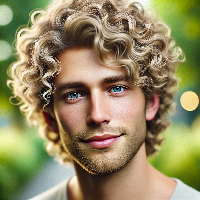

In [18]:
img

In [17]:
print("Answer 2:", img.size)

Answer 2: (200, 200)


### Question 3. First R value after pre-processing

In [20]:
import numpy as np

In [28]:
# Convert to numpy array
x = np.array(img)  # Shape: (200, 200, 3), values 0-255

# Preprocess (same as your previous homework transforms):
# 1. Scale to 0-1 (like ToTensor does)
x = x / 255.0

# 2. Normalize with ImageNet mean and std
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
x = (x - mean) / std

# Get the first pixel, R channel
first_pixel_r_channel = x[0, 0, 0]

print(f"Answer 3: {first_pixel_r_channel:.4f}")

Answer 3: -1.0733


### Question 4. Model output

In [23]:
!pip3 install onnxruntime

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 535.2 kB/s  0:00:32m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 497.7 kB/s  0:00:12 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 406.8 kB/s  0:00:01m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [onnxruntime] [onnxruntime]


In [29]:
import onnxruntime as ort

# Load the ONNX model with onnxruntime
session = ort.InferenceSession("hair_classifier_v1.onnx")

# Get input and output names
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print(f"Input name: {input_name}")
print(f"Output name: {output_name}")

# Convert from (H, W, C) to (C, H, W) for PyTorch format
x = np.transpose(x, (2, 0, 1))  # (200, 200, 3) -> (3, 200, 200)

# Add batch dimension: (C, H, W) -> (1, C, H, W)
x = np.expand_dims(x, axis=0)  # (3, 200, 200) -> (1, 3, 200, 200)

# Convert to float32
x = x.astype(np.float32)

Input name: input
Output name: output


In [31]:
# Run inference
outputs = session.run([output_name], {input_name: x})

# Get the output (logit value)
prediction = outputs[0]
print(f"Model output (logit): {prediction}")

# Apply sigmoid to get probability
probability = 1 / (1 + np.exp(-prediction))
print(f"Probability: {probability}")

# Binary prediction
binary_prediction = (probability > 0.5).astype(int)
print(f"Binary prediction: {binary_prediction}")

print("Answer 4:", probability)

Model output (logit): [[0.09156641]]
Probability: [[0.52287567]]
Binary prediction: [[1]]
Answer 4: [[0.52287567]]


### Question 5. Docker image size

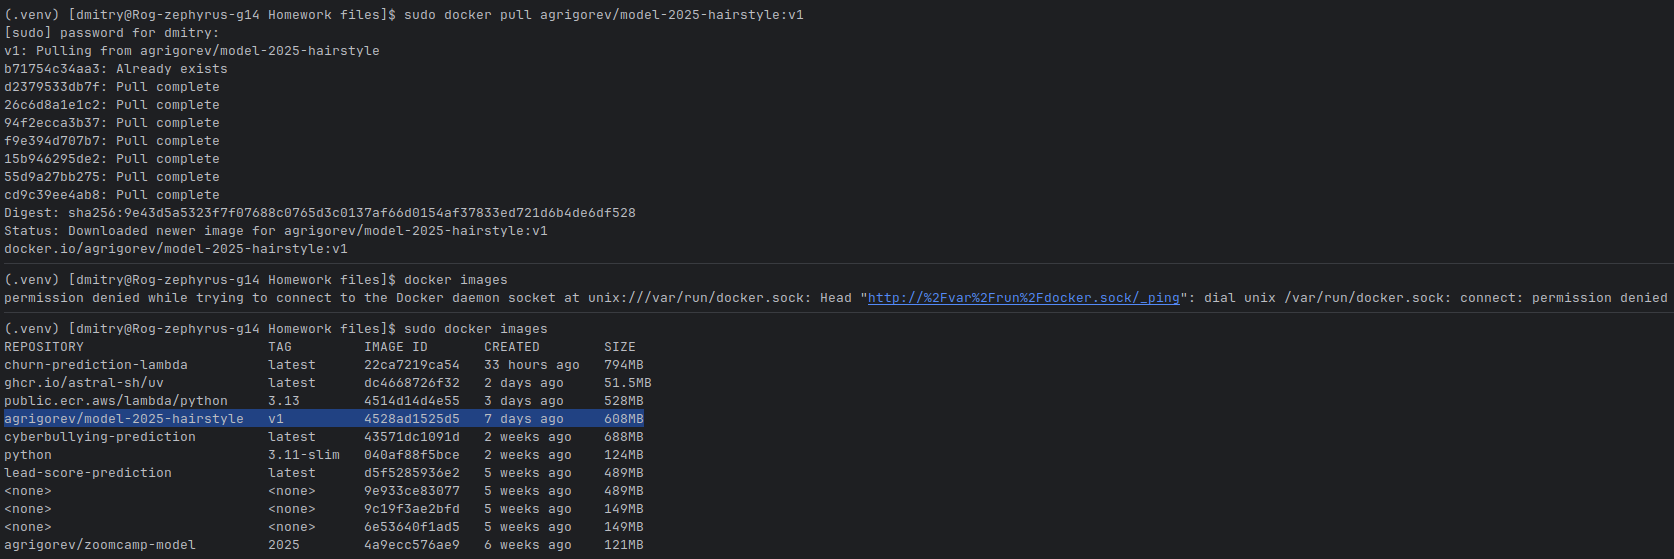

Answer 5: 608MB

### Question 6. Model output (docker)